<a href="https://colab.research.google.com/github/Johnogunlola/MRes-AI/blob/MRes/Customer_Buying_Behaviour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# 1. IMPORT LIBRARIES AND LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

In [5]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [7]:
# Load the Excel file
file_path = "/content/customer_booking.xlsx"

df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
display(df.head())

Dataset shape: (50000, 14)

First five rows:


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [8]:
# ============================================================
# 2. EXPLORE THE DATASET
# ============================================================

print("Dataset information:")
print(df.info())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

display(missing.sort_values("Missing_Count", ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic numerical statistics:")
display(df.describe().T)

print("\nCategorical / all-column statistics:")
display(df.describe(include="all").T)

print("\nNumber of unique values in each column:")
display(df.nunique().sort_values(ascending=False))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5

,Missing_Count,Missing_Percentage
num_passengers,0,0.0
sales_channel,0,0.0
trip_type,0,0.0
purchase_lead,0,0.0
length_of_stay,0,0.0
flight_hour,0,0.0
flight_day,0,0.0
route,0,0.0
booking_origin,0,0.0
wants_extra_baggage,0,0.0



Duplicate rows: 719

Basic numerical statistics:


,count,mean,std,min,25%,50%,75%,max
num_passengers,50000.0,1.591240,1.020165,1.00,1.00,1.00,2.00,9.0
purchase_lead,50000.0,84.940480,90.451378,0.00,21.00,51.00,115.00,867.0
length_of_stay,50000.0,23.044560,33.887670,0.00,5.00,17.00,28.00,778.0
flight_hour,50000.0,9.066340,5.412660,0.00,5.00,9.00,13.00,23.0
wants_extra_baggage,50000.0,0.668780,0.470657,0.00,0.00,1.00,1.00,1.0
wants_preferred_seat,50000.0,0.296960,0.456923,0.00,0.00,0.00,1.00,1.0
wants_in_flight_meals,50000.0,0.427140,0.494668,0.00,0.00,0.00,1.00,1.0
flight_duration,50000.0,7.277561,1.496863,4.67,5.62,7.57,8.83,9.5
booking_complete,50000.0,0.149560,0.356643,0.00,0.00,0.00,0.00,1.0



Categorical / all-column statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
num_passengers,50000.0,NaN,NaN,NaN,1.59124,1.020165,1.0,1.0,1.0,2.0,9.0
sales_channel,50000,2,Internet,44382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_type,50000,3,RoundTrip,49497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_lead,50000.0,NaN,NaN,NaN,84.94048,90.451378,0.0,21.0,51.0,115.0,867.0
length_of_stay,50000.0,NaN,NaN,NaN,23.04456,33.88767,0.0,5.0,17.0,28.0,778.0
flight_hour,50000.0,NaN,NaN,NaN,9.06634,5.41266,0.0,5.0,9.0,13.0,23.0
flight_day,50000,7,Mon,8102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route,50000,799,AKLKUL,2680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_origin,50000,104,Australia,17872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wants_extra_baggage,50000.0,NaN,NaN,NaN,0.66878,0.470657,0.0,0.0,1.0,1.0,1.0



Number of unique values in each column:


,0
route,799
purchase_lead,470
length_of_stay,335
booking_origin,104
flight_hour,24
flight_duration,21
num_passengers,9
flight_day,7
trip_type,3
sales_channel,2


Target variable: booking_complete


,Count,Percentage
booking_complete,,
0,42522,85.04
1,7478,14.96


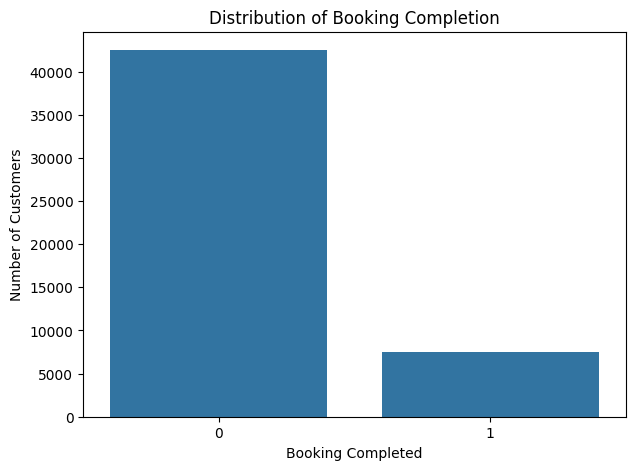

In [9]:
# ============================================================
# 3. EXPLORE TARGET VARIABLE
# ============================================================

target = "booking_complete"

print("Target variable:", target)

target_counts = df[target].value_counts()
target_percentages = df[target].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

display(target_summary)

# Visualise target balance
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x=target)

plt.title("Distribution of Booking Completion")
plt.xlabel("Booking Completed")
plt.ylabel("Number of Customers")
plt.show()

In [10]:
# ============================================================
# 4. EXPLORE CATEGORICAL VARIABLES
# ============================================================

categorical_columns = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts().head(15))


--- sales_channel ---
Number of unique values: 2
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

--- trip_type ---
Number of unique values: 3
trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

--- flight_day ---
Number of unique values: 7
flight_day
Mon    8102
Wed    7674
Tue    7673
Thu    7424
Fri    6761
Sun    6554
Sat    5812
Name: count, dtype: int64

--- route ---
Number of unique values: 799
route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649
MELTPE     644
SGNSYD     614
DMKSYD     532
COKSYD     511
COKMEL     474
Name: count, dtype: int64

--- booking_origin ---
Number of unique values: 104
booking_origin
Australia        17872
Malaysia          7174
South Korea       4559
Japan             3885
China             3387
Indonesia         2369
Taiwan            2077
Thailand          2030
India      

In [11]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

def create_features(data):
    data = data.copy()

    # --------------------------------------------------------
    # Number of additional services requested
    # --------------------------------------------------------
    data["total_extra_services"] = (
        data["wants_extra_baggage"]
        + data["wants_preferred_seat"]
        + data["wants_in_flight_meals"]
    )

    # --------------------------------------------------------
    # Weekend indicator
    # --------------------------------------------------------
    data["is_weekend"] = data["flight_day"].isin(["Sat", "Sun"]).astype(int)

    # --------------------------------------------------------
    # Time-of-day categories
    # --------------------------------------------------------
    data["flight_hour_period"] = pd.cut(
        data["flight_hour"],
        bins=[-1, 5, 11, 17, 23],
        labels=["Night", "Morning", "Afternoon", "Evening"]
    )

    # --------------------------------------------------------
    # Log transformations for heavily skewed variables
    # +1 prevents log(0)
    # --------------------------------------------------------
    data["purchase_lead_log"] = np.log1p(data["purchase_lead"])
    data["length_of_stay_log"] = np.log1p(data["length_of_stay"])

    # --------------------------------------------------------
    # Relationship between purchase lead and length of stay
    # --------------------------------------------------------
    data["lead_per_stay"] = (
        data["purchase_lead"] / (data["length_of_stay"] + 1)
    )

    # --------------------------------------------------------
    # Extract route origin and destination
    #
    # The route values are generally represented as
    # six-character airport-code combinations, e.g. AKLKUL.
    # --------------------------------------------------------
    data["route_origin"] = data["route"].str[:3]
    data["route_destination"] = data["route"].str[-3:]

    # --------------------------------------------------------
    # Whether the customer requested any additional service
    # --------------------------------------------------------
    data["requested_extra_service"] = (
        data["total_extra_services"] > 0
    ).astype(int)

    return data


df_model = create_features(df)

print("Original number of columns:", df.shape[1])
print("Number of columns after feature engineering:", df_model.shape[1])

display(df_model.head())

Original number of columns: 14
Number of columns after feature engineering: 23


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,total_extra_services,is_weekend,flight_hour_period,purchase_lead_log,length_of_stay_log,lead_per_stay,route_origin,route_destination,requested_extra_service
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,1,1,Morning,5.572154,2.995732,13.100000,AKL,DEL,1
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,0,1,Night,4.727388,3.044522,5.333333,AKL,DEL,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0,2,0,Afternoon,5.497168,3.135494,10.565217,AKL,DEL,1
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,1,1,Night,4.574711,3.465736,3.000000,AKL,DEL,1
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0,2,0,Afternoon,4.234107,3.135494,2.956522,AKL,DEL,1


In [12]:
# ============================================================
# 6. DEFINE X AND y
# ============================================================

X = df_model.drop(columns=[target])
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True))

X shape: (50000, 22)
y shape: (50000,)

Target distribution:
booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64


In [13]:
# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training observations: 40000
Testing observations: 10000

Training target distribution:
booking_complete
0    0.85045
1    0.14955
Name: proportion, dtype: float64

Testing target distribution:
booking_complete
0    0.8504
1    0.1496
Name: proportion, dtype: float64


In [14]:
# ============================================================
# 8. PREPROCESSING
# ============================================================

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Categorical features:
['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin', 'flight_hour_period', 'route_origin', 'route_destination']

Numerical features:
['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'total_extra_services', 'is_weekend', 'purchase_lead_log', 'length_of_stay_log', 'lead_per_stay', 'requested_extra_service']


In [16]:
# ============================================================
# 9. RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['num_passengers',
                                                   'purchase_lead',
                                                   'length_of_stay',
                                                   'flight_hour',
                                                   'wants_extra_baggage',
                                                   'wants_preferred_seat',
                                                   'wants_in_flight_meals',
                                                   'flight_duration',
                                                   'total_extra_services',
                                                   'is_weekend',
                     

In [17]:
# ============================================================
# 10. 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    "Metric": scoring.keys(),
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean(),
        cv_results["test_pr_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std(),
        cv_results["test_pr_auc"].std()
    ]
})

display(cv_summary)

,Metric,Mean,Std
0,accuracy,0.790450,0.005351
1,precision,0.366060,0.010476
2,recall,0.547807,0.018502
3,f1,0.438781,0.012136
4,roc_auc,0.791698,0.005510
5,pr_auc,0.381069,0.008760


In [18]:
# ============================================================
# 11. TRAIN FINAL MODEL
# ============================================================

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [19]:
# ============================================================
# 12. TEST SET EVALUATION
# ============================================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

display(test_metrics)

,Metric,Score
0,Accuracy,0.789700
1,Precision,0.371670
2,Recall,0.587567
3,F1 Score,0.455322
4,ROC-AUC,0.799899
5,PR-AUC,0.399061


In [20]:
# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Booking Not Completed",
        "Booking Completed"
    ]
))

                       precision    recall  f1-score   support

Booking Not Completed       0.92      0.83      0.87      8504
    Booking Completed       0.37      0.59      0.46      1496

             accuracy                           0.79     10000
            macro avg       0.65      0.71      0.66     10000
         weighted avg       0.84      0.79      0.81     10000



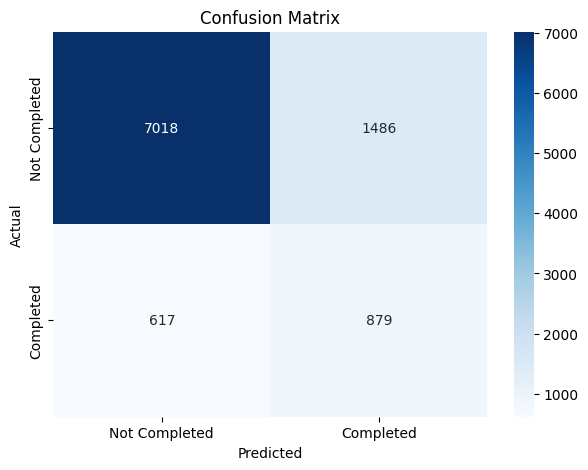

In [21]:
# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Completed",
        "Completed"
    ],
    yticklabels=[
        "Not Completed",
        "Completed"
    ]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 700x500 with 0 Axes>

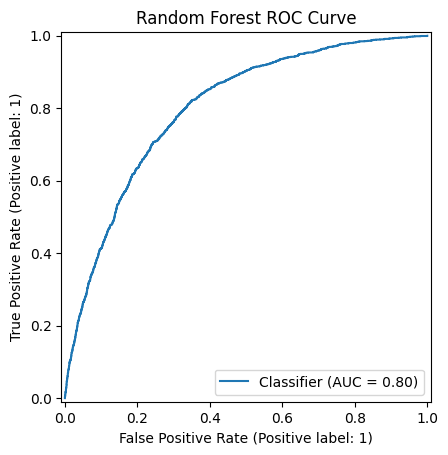

In [22]:
# ============================================================
# 15. ROC CURVE
# ============================================================

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Random Forest ROC Curve")
plt.show()

In [23]:
# ============================================================
# 16. PERMUTATION FEATURE IMPORTANCE
# ============================================================

print("Calculating permutation importance...")

perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    "Importance_Mean",
    ascending=False
)

display(importance_df)

Calculating permutation importance...


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Feature,Importance_Mean,Importance_Std
8,booking_origin,0.116484,0.002357
19,route_origin,0.012769,0.001003
7,route,0.010859,0.000685
1,sales_channel,0.009667,0.001464
20,route_destination,0.008866,0.000711
4,length_of_stay,0.004074,0.000330
17,length_of_stay_log,0.003824,0.000653
12,flight_duration,0.003120,0.000712
9,wants_extra_baggage,0.002670,0.000544
10,wants_preferred_seat,0.002312,0.000268


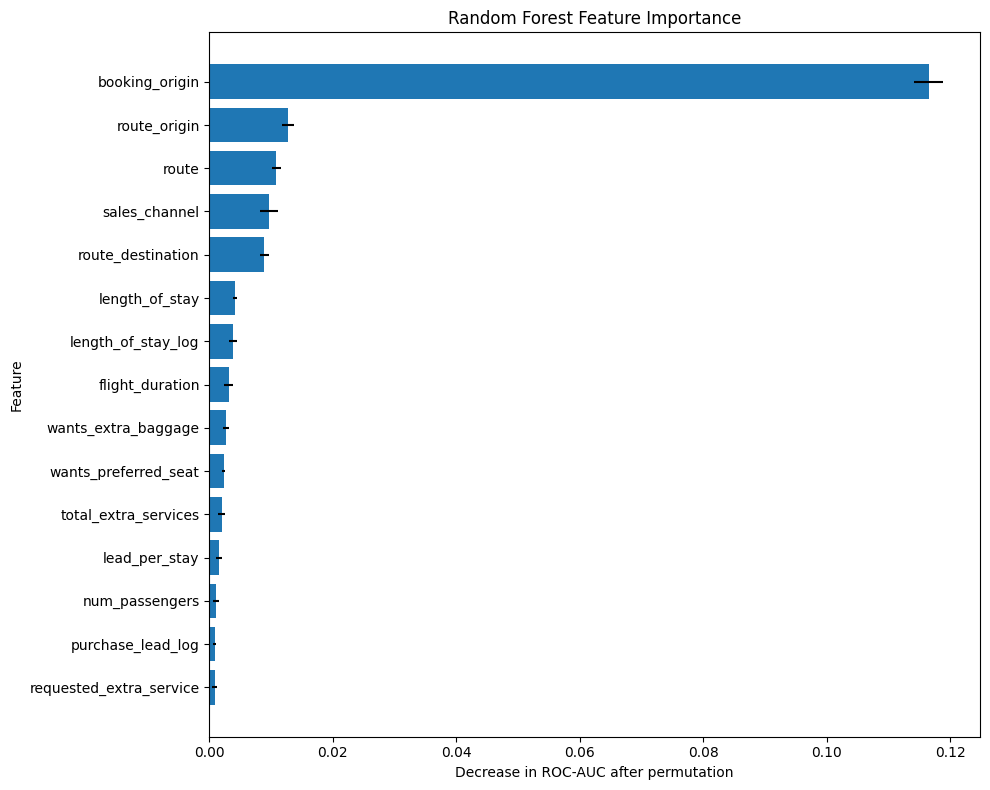

In [24]:
# ============================================================
# 17. FEATURE IMPORTANCE VISUALISATION
# ============================================================

top_n = 15

plot_data = importance_df.head(top_n).sort_values(
    "Importance_Mean",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance_Mean"],
    xerr=plot_data["Importance_Std"]
)

plt.xlabel("Decrease in ROC-AUC after permutation")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# 18. CROSS-VALIDATION VS TEST PERFORMANCE
# ============================================================

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Cross-validation Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean(),
        cv_results["test_pr_auc"].mean()
    ],
    "Test Set": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

display(comparison)

,Metric,Cross-validation Mean,Test Set
0,Accuracy,0.790450,0.789700
1,Precision,0.366060,0.371670
2,Recall,0.547807,0.587567
3,F1,0.438781,0.455322
4,ROC-AUC,0.791698,0.799899
5,PR-AUC,0.381069,0.399061


In [26]:
# ============================================================
# 19. NUMERICAL VARIABLE RELATIONSHIPS WITH TARGET
# ============================================================

numerical_for_analysis = [
    col for col in df_model.select_dtypes(
        include=["int64", "float64"]
    ).columns
    if col != target
]

correlations = (
    df_model[numerical_for_analysis + [target]]
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

display(correlations.to_frame("Correlation with booking_complete"))

,Correlation with booking_complete
flight_duration,-0.106266
length_of_stay_log,-0.090568
wants_extra_baggage,0.068139
total_extra_services,0.067828
requested_extra_service,0.061731
wants_preferred_seat,0.050116
length_of_stay,-0.042408
lead_per_stay,0.032952
purchase_lead_log,-0.031765
wants_in_flight_meals,0.026511



Booking completion rate by sales_channel:


,sales_channel,booking_complete
0,Internet,15.476995
1,Mobile,10.840157


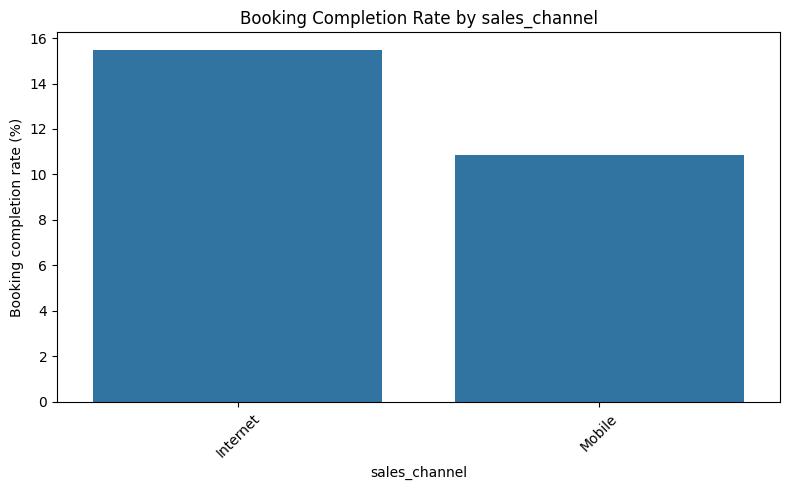


Booking completion rate by trip_type:


,trip_type,booking_complete
0,RoundTrip,15.057478
1,OneWay,5.167959
2,CircleTrip,4.310345


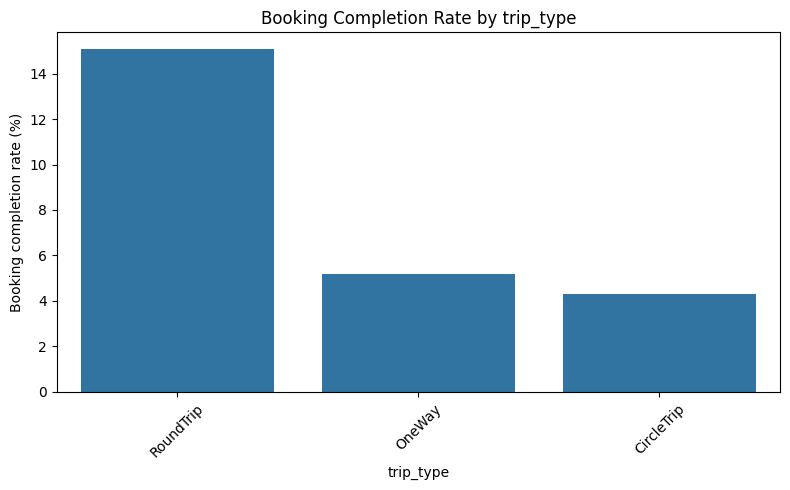


Booking completion rate by flight_day:


,flight_day,booking_complete
0,Wed,16.314829
1,Thu,15.113147
2,Mon,14.860528
3,Sat,14.814178
4,Tue,14.713932
5,Fri,14.539269
6,Sun,14.144034


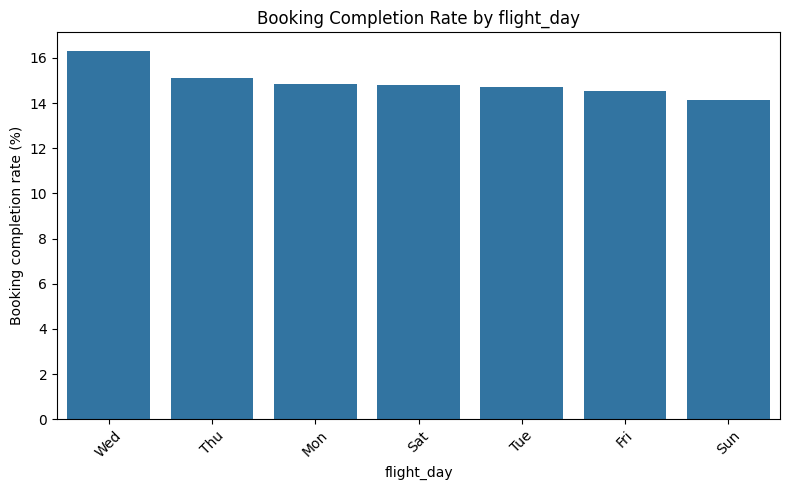

In [27]:
# ============================================================
# 20. BOOKING RATE BY CATEGORICAL VARIABLES
# ============================================================

categorical_to_explore = [
    "sales_channel",
    "trip_type",
    "flight_day"
]

for col in categorical_to_explore:

    booking_rate = (
        df_model.groupby(col)[target]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    booking_rate[target] *= 100

    print(f"\nBooking completion rate by {col}:")
    display(booking_rate)

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=booking_rate,
        x=col,
        y=target
    )

    plt.ylabel("Booking completion rate (%)")
    plt.xlabel(col)
    plt.title(f"Booking Completion Rate by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [28]:
# ============================================================
# 21. SAVE RESULTS
# ============================================================

importance_df.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

test_metrics.to_csv(
    "model_test_metrics.csv",
    index=False
)

cv_summary.to_csv(
    "cross_validation_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
